In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np

from torchdiffeq import odeint
import sindy_tools

A_mat = torch.tensor([[0.0, 3.0], [-1.0, -0.2]])

def damped_oscillator(t, state):
    """
    Damped oscillator system dynamics.

    Args:
        t: Time point (unused, but required by odeint)
        state: Tensor of shape [2, 1] with state variables [position, velocity]

    Returns:
        Tensor of shape [2, 1] with derivatives
    """
    # state shape: [2, 1]
    return A_mat @ state

x0 = torch.tensor([[1.0], [0.0]])  # Shape: [2, 1]
t_span = torch.linspace(0, 10, 501)

# Generate the ground truth solution
true_solution = odeint(damped_oscillator, x0.flatten(), t_span)

# Add noise to the solution
nl = 0.1
noise = nl * torch.randn(true_solution.shape)
X_data = true_solution + noise # n_t, n_states

In [2]:
lib = sindy_tools.create_sindy_library(X_data.shape[1], 2, True)
Theta = lib(X_data) # n_t, P, where P depends on degree and original n_states

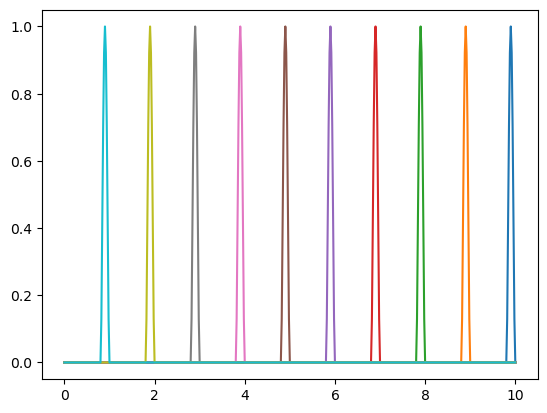

In [3]:
from typing import Tuple

def make_polynomial_bump(t_grid: torch.Tensor,
                         a: float,
                         b: float,
                         p: int = 2,
                         ) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Evaluate a polynomial bump test function φ(t) = C*(t-a)^p*(b-t)^q over a time grid,
    and its derivative φ'(t). The function is 0 outside of (a, b).

    Inputs:
        t_grid   : Tensor of shape (N,) representing time points
        a, b     : float, start and end of support (a < b)
        normalize: if True, scale φ so that max|φ| = 1

    Returns:
        phi      : (N,) tensor, values of φ(t)
        dphi     : (N,) tensor, values of φ'(t)
    """
    t = t_grid

    # Mask for (a < t < b)
    mask = (t > a) & (t < b)

    # Compute unnormalized bump on support
    t_local = t[mask]
    tma = t_local - a
    bmt = b - t_local

    phi_local = tma**p * bmt**p
    dphi_local = (
        p * tma**(p - 1) * bmt**p -
        p * tma**p * bmt**(p - 1)
    )

    # Normalization constant (ensures max is 1)
    max_phi = torch.max(phi_local)
    phi_local = phi_local / max_phi
    dphi_local = dphi_local / max_phi

    # Fill full arrays
    phi = torch.zeros_like(t)
    dphi = torch.zeros_like(t)

    phi[mask] = phi_local
    dphi[mask] = dphi_local

    return phi, dphi

width = 5 # L, half width, minimum 1, includes center point, so width = 3 gives 5 points (2*width - 1)
include_endpoints = False # whether or not the basis functions should be nonzero at t_span endpoints
# stride = 2
stride = 2*width # no overlap!

center = len(t_span) - width - 1 # minimum width, maximum len(t_span) - width - 1
a = center - width
b = center + width
# phi, dphi = make_polynomial_bump(t_span, a=t_span[a], b=t_span[b], p=2)

# plt.plot(t_span, phi, '--k', label='Bump function φ(t)')
# plt.plot(t_span, dphi, '--k', label='Bump function derivative φ\'(t)')
# plt.grid()


# Create big Phi, containing all test functions! (and dPhi)
# there will be K of these, where K depends on the width, which restricts allowable centers
N = len(t_span)
L = 2*width + 1
dt = t_span[1] - t_span[0]
if include_endpoints:
    t_span_ext = torch.cat((torch.tensor([t_span[0]-dt]), t_span, torch.tensor([t_span[-1]+dt])))
else:
    t_span_ext = t_span

N_ext = len(t_span_ext)

# %% compute K using "valid" conv formula in index space
# number of starting positions: floor((N_ext - L)/stride) + 1
K = (N_ext - L) // stride + 1
Phi = torch.zeros((len(t_span), K))
dPhi = torch.zeros((len(t_span), K))

for k in range(K):
    start = N_ext - L - k*stride      # start positions step left from the rightmost
    end   = start + L                 # one-past the last index of the support
    a = t_span_ext[start]             # left time‐value of this bump
    b = t_span_ext[end - 1]           # right time‐value of this bump

    phi, dphi = make_polynomial_bump(t_span, a=a, b=b, p=2)
    Phi[:, k]  = phi
    dPhi[:, k] = dphi


plt.figure()
if K < 10:
    plt.plot(t_span, Phi, label='Bump function φ(t)')
else:
    k_inds = np.arange(0, K, K//10).astype(int)
    plt.plot(t_span, Phi[:, k_inds], label='Bump function φ(t)')

# plt.figure()
# plt.plot(t_span, dPhi[:,-1], label='Bump function derivative φ\'(t)')

# plt.plot(t_span, Theta)

# dot(Y) = Theta @ Xi
# (n_t, n_state) = (n_t, P) @ (P, n_state))

# Or weak form
# (K, n_state) = (K, P) @ (P, n_state)

In [4]:
print(f'Phi: {Phi.unsqueeze(2).shape}')
print(f'Theta: {Theta.unsqueeze(1).shape}')
Theta_Phi = torch.bmm(Phi.unsqueeze(2), Theta.unsqueeze(1))
print(f'Theta_Phi: {Theta_Phi.shape}')

X_data_dPhi = torch.bmm(dPhi.unsqueeze(2), X_data.unsqueeze(1))
print(f'X_data_dPhi: {X_data_dPhi.shape}')
# X_data_dPhi = dPhi.T @ X_data

Phi: torch.Size([501, 50, 1])
Theta: torch.Size([501, 1, 6])
Theta_Phi: torch.Size([501, 50, 6])
X_data_dPhi: torch.Size([501, 50, 2])


In [5]:
# Integrate out the time dimension
rhs_mat = torch.trapezoid(X_data_dPhi, dx=dt, dim=0)  # now just K,P
lhs_vec = -torch.trapezoid(Theta_Phi, dx=dt, dim=0) # now just K,n_states
print(f'lhs_vec.shape: {lhs_vec.shape}')
print(f'rhs_mat.shape: {rhs_mat.shape}')

rcond = None
rtol = 1e-3
atol = 1e-5

Xi = torch.linalg.lstsq(lhs_vec, rhs_mat, rcond=rcond).solution
goal_Xi = torch.tensor([[0.0, 0.0], [A_mat[0, 0], A_mat[1,0]],
                        [A_mat[0, 1], A_mat[1,1]], [0.0, 0.0],
                        [0.0, 0.0], [0.0, 0.0]])
Xi_error_weak = Xi - goal_Xi
# get y_pred via integrating
predictor = sindy_tools.create_predictor(Xi, lib)
sindy_system = lambda t, state: predictor(state)  # SINDy system function
x_pred = odeint(sindy_system, x0, t_span, rtol=rtol, atol=atol).squeeze()
# get error at end
error_pred_weak = torch.linalg.norm(x_pred[-1] - true_solution[-1]) / torch.linalg.norm(true_solution[-1])


dxdt = sindy_tools.get_derivative(dt, X_data)  # Shape: [98, 2]
Theta_m2 = Theta[1:-1]  # Shape: [98, P] to match dxdt shape
# Xi shape: [P, 2] - Each column represents coefficients for one state variable
Xi_strong = torch.linalg.lstsq(Theta_m2, dxdt, rcond=rcond).solution
Xi_error_strong = Xi_strong - goal_Xi

predictor_strong = sindy_tools.create_predictor(Xi_strong, lib)
sindy_system_strong = lambda t, state: predictor_strong(state)  # SINDy system function
x_pred_strong = odeint(sindy_system_strong, x0, t_span, rtol=rtol, atol=atol).squeeze()
# get error at end
error_pred_strong = torch.linalg.norm(x_pred_strong[-1] - true_solution[-1]) / torch.linalg.norm(true_solution[-1])

coeff_error_weak = torch.linalg.norm(Xi_error_weak, ord=1) / torch.linalg.norm(goal_Xi, ord=1)
coeff_error_strong = torch.linalg.norm(Xi_error_strong, ord=1) / torch.linalg.norm(goal_Xi, ord=1)

print(f'coeff_error_weak: {coeff_error_weak}')
print(f'coeff_error_strong: {coeff_error_strong}')
print(f'error_pred_weak: {error_pred_weak}')
print(f'error_pred_strong: {error_pred_strong}')

# create dicts to store these for multiple runs. Check if it exists, if not create
# if it does, append to it
# just save errors
# also add nl to this
try:
    dict_errors
except NameError:
    dict_errors = {}
    dict_errors['nl'] = []
    dict_errors['coeff_error_weak'] = []
    dict_errors['coeff_error_strong'] = []
    dict_errors['error_pred_weak'] = []
    dict_errors['error_pred_strong'] = []

dict_errors['nl'].append(nl)
dict_errors['coeff_error_weak'].append(coeff_error_weak.item())
dict_errors['coeff_error_strong'].append(coeff_error_strong.item())
dict_errors['error_pred_weak'].append(error_pred_weak.item())
dict_errors['error_pred_strong'].append(error_pred_strong.item())

lhs_vec.shape: torch.Size([50, 6])
rhs_mat.shape: torch.Size([50, 2])
coeff_error_weak: 1.0958328247070312
coeff_error_strong: 0.907001256942749
error_pred_weak: 4.119994163513184
error_pred_strong: 2.45068097114563


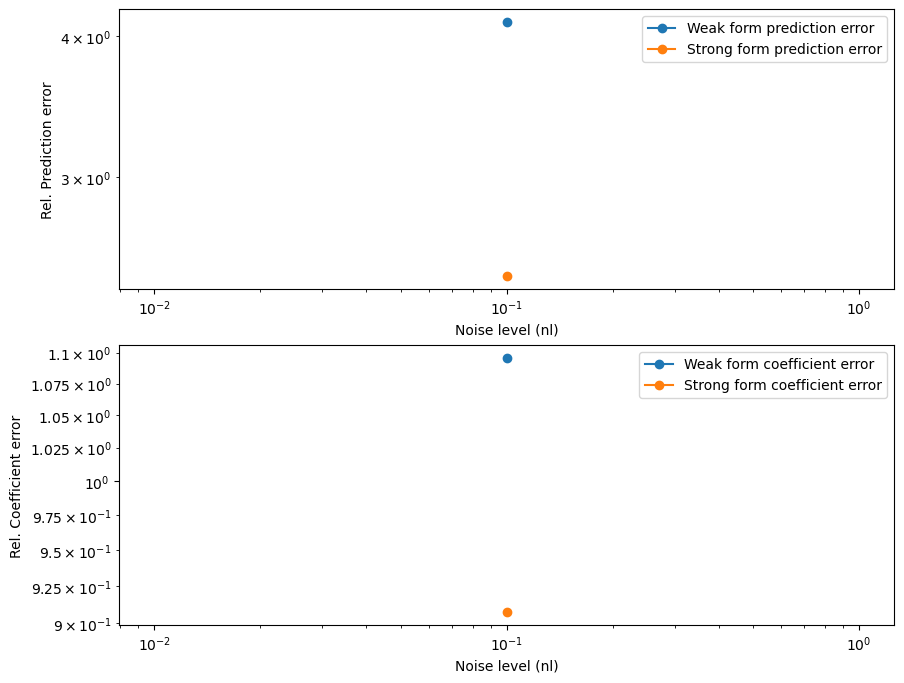

In [6]:
# sort dict by nl
sort_inds = np.argsort(dict_errors['nl'])
# just sort for each key in dict
for key in dict_errors.keys():
    dict_errors[key] = list(np.array(dict_errors[key])[sort_inds])


# plot these metrics vs nl for the two methods. two subplots, nl on x on both. first subplot is prediction error, 2nd is coefficient error
fig, ax = plt.subplots(2, 1, figsize=(10, 8))
ax[0].plot(dict_errors['nl'], dict_errors['error_pred_weak'], 'o-', label='Weak form prediction error')
ax[0].plot(dict_errors['nl'], dict_errors['error_pred_strong'], 'o-', label='Strong form prediction error')
ax[0].set_xlabel('Noise level (nl)')
ax[0].set_ylabel('Rel. Prediction error')
ax[0].set_yscale('log')
ax[0].set_xscale('log')
ax[0].legend()

ax[1].plot(dict_errors['nl'], dict_errors['coeff_error_weak'], 'o-', label='Weak form coefficient error')
ax[1].plot(dict_errors['nl'], dict_errors['coeff_error_strong'], 'o-', label='Strong form coefficient error')
ax[1].set_xlabel('Noise level (nl)')
ax[1].set_ylabel('Rel. Coefficient error')
ax[1].set_yscale('log')
ax[1].set_xscale('log')
ax[1].legend()
